# 02 — Deep Learning en PyTorch : Embeddings, LSTM et GRU


Dans ce notebook, nous prolongeons l’analyse baseline fondée sur les modèles classiques de NLP (Bag-of-Words, TF-IDF, régression logistique, SVM) en explorant des modèles de deep learning implémentés avec **PyTorch**.

L’objectif est d’évaluer si des modèles séquentiels, capables de prendre en compte l’ordre des mots et des dépendances plus longues dans les textes, permettent de mieux capturer les différences discursives entre les professions de foi classées à gauche et à droite.

La démarche suivie dans ce notebook est la suivante :

1. charger le jeu de données final ;
2. effectuer un **dé-biaisage contrôlé** du texte afin de limiter l’effet des mots trop évidents ou directement liés aux étiquettes politiques ;
3. préparer les données pour PyTorch ;
4. construire un vocabulaire et représenter les textes sous forme de séquences d’indices ;
5. entraîner deux modèles séquentiels : **LSTM** et **GRU** ;
6. comparer leurs performances à la baseline classique obtenue précédemment.

Cette approche permet de répondre à une question importante du projet :  
**les modèles profonds capturent-ils des structures discursives plus riches que les modèles linéaires, ou les méthodes classiques restent-elles suffisantes sur ce corpus ?**

## 0. Paquets

Ce notebook utilise `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn` et `torch`.


In [7]:
%pip install pandas numpy matplotlib seaborn scikit-learn torch

Note: you may need to restart the kernel to use updated packages.


In [8]:
import sys, torch
print(sys.executable)
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.device_count())

/opt/python/bin/python
2.11.0+cu130
False
13.0
1


## 1. Imports et configuration

In [9]:
import re
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

In [10]:
DATA_PATH = Path("../data/processed/dataset_1993_final_clean.csv")
assert DATA_PATH.exists(), f"Fichier introuvable : {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(2523, 3)


,id,text,label
0,EL189_L_1993_03_001_01_1_PF_01,elections legislatives de mars 93 front nation...,right
1,EL189_L_1993_03_001_01_1_PF_02,sciences po / fonds cevipof république françai...,left
2,EL189_L_1993_03_001_01_1_PF_03,sciences po / fonds cevipof elections législat...,right
3,EL189_L_1993_03_001_01_1_PF_04,elections législatives du 21 mars 1993 pourquo...,left
4,EL189_L_1993_03_001_01_1_PF_06,sciences po / fonds cevipof elections legislat...,left


## 3. Vérifications préliminaires

Cette étape permet de vérifier la qualité du jeu de données avant l’entraînement :

- présence ou non de valeurs manquantes ;
- équilibre entre les classes ;
- existence éventuelle de doublons.

Ces contrôles sont importants, car un dataset déséquilibré ou bruité peut fortement influencer les performances du modèle et rendre l’interprétation trompeuse.

In [11]:
print(df.columns.tolist())
print()
print(df.isna().sum())
print()
print(df["label"].value_counts(dropna=False))
print()
print("Doublons texte+label :", df.duplicated(subset=["text", "label"]).sum())

['id', 'text', 'label']

id       0
text     0
label    0
dtype: int64

label
right    1351
left     1172
Name: count, dtype: int64

Doublons texte+label : 0


## 4. Dé-biaisage contrôlé du texte

Les analyses précédentes ont montré que certains mots influençaient fortement la prédiction, notamment :

- les noms de partis ;
- les étiquettes explicites comme *gauche* ou *droite* ;
- certains mots extrêmement discriminants repérés dans la baseline.

Pour tester la robustesse des modèles, nous construisons ici une version **dé-biaisée** du texte.  
L’idée n’est pas de supprimer arbitrairement des mots, mais de réduire le poids des indices les plus évidents afin de vérifier si le modèle est encore capable de distinguer les orientations politiques à partir de structures discursives plus profondes.

Cette étape constitue donc une **expérience contrôlée** : si les performances restent élevées après dé-biaisage, cela suggère que le modèle apprend bien au-delà de simples mots-clés.

In [12]:
EXPLICIT_PHRASES = [
    "parti socialiste",
    "parti communiste",
    "parti communiste français",
    "front national",
    "rassemblement pour la république",
    "union pour la démocratie française",
]

EXPLICIT_TOKENS = [
    "gauche", "droite",
    "parti", "socialiste", "communiste",
    "rpr", "udf", "cni",
    "front", "national",
]

GENERIC_CORPUS_TERMS = [
    "sciences", "po", "fonds", "cevipof",
    "elections", "élections", "legislatives", "législatives",
    "mars", "1993", "république", "française", "francaise",
]

ALL_SINGLE_TOKENS_TO_REMOVE = sorted(
    set(EXPLICIT_TOKENS + GENERIC_CORPUS_TERMS)
)

In [13]:
TOKEN_PATTERN = re.compile(r"[a-zàâçéèêëîïôûùüÿñæœ'-]+")

def normalize_text(text: str) -> str:
    text = str(text).lower()
    text = text.replace("\n", " ").replace("\r", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def remove_phrases(text: str, phrases):
    text_out = text
    for phrase in sorted(phrases, key=len, reverse=True):
        text_out = re.sub(rf"\b{re.escape(phrase.lower())}\b", " ", text_out)
    return re.sub(r"\s+", " ", text_out).strip()

def tokenize_and_filter(text: str, single_tokens_to_remove):
    tokens = TOKEN_PATTERN.findall(text)
    filtered = []
    remove_set = set(single_tokens_to_remove)
    for tok in tokens:
        if tok in remove_set:
            continue
        if tok.isdigit():
            continue
        if len(tok) < 2:
            continue
        filtered.append(tok)
    return filtered

def debias_text(text: str):
    text = normalize_text(text)
    text = remove_phrases(text, EXPLICIT_PHRASES)
    tokens = tokenize_and_filter(text, ALL_SINGLE_TOKENS_TO_REMOVE)
    return tokens

df["tokens_debiased"] = df["text"].apply(debias_text)
df["text_debiased"] = df["tokens_debiased"].apply(lambda toks: " ".join(toks))
df[["label", "text", "text_debiased"]].head(3)

,label,text,text_debiased
0,right,elections legislatives de mars 93 front nation...,de les français d'abord bernard aulagne ans ma...
1,left,sciences po / fonds cevipof république françai...,département de l'ain circonscription lionel mo...
2,right,sciences po / fonds cevipof elections législat...,de re circonscription de l'ain jacques boyon a...


## 5. Contrôle qualité après dé-biaisage

In [14]:
df["orig_len_words"] = df["text"].astype(str).str.split().str.len()
df["debiased_len_words"] = df["text_debiased"].astype(str).str.split().str.len()

print(df[["orig_len_words", "debiased_len_words"]].describe())
print()
print("Textes vides après dé-biaisage :", (df["text_debiased"].str.len() == 0).sum())

       orig_len_words  debiased_len_words
count     2523.000000         2523.000000
mean       770.743956          682.264368
std        307.105131          282.908640
min         47.000000           35.000000
25%        536.000000          473.500000
50%        783.000000          697.000000
75%        925.000000          802.000000
max       2651.000000         2396.000000

Textes vides après dé-biaisage : 0


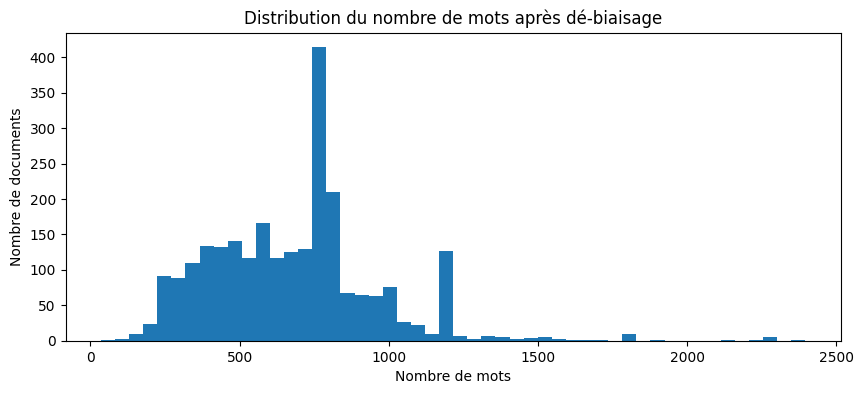

In [15]:
plt.figure(figsize=(10, 4))
plt.hist(df["debiased_len_words"], bins=50)
plt.title("Distribution du nombre de mots après dé-biaisage")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de documents")
plt.show()

## 6. Nettoyage final avant Deep Learning

- on retire les textes vides
- on retire les doublons exacts sur `text_debiased + label`
- on gère les éventuels textes contradictoires


In [16]:
df_dl = df[df["text_debiased"].str.strip().str.len() > 0].copy()

conflict_texts = (
    df_dl.groupby("text_debiased")["label"]
    .nunique()
    .loc[lambda s: s > 1]
    .index
)
print("Nombre de textes contradictoires :", len(conflict_texts))

df_dl = df_dl[~df_dl["text_debiased"].isin(conflict_texts)].copy()

before = len(df_dl)
df_dl = df_dl.drop_duplicates(subset=["text_debiased", "label"]).copy()
after = len(df_dl)

print("Lignes avant déduplication :", before)
print("Lignes après déduplication :", after)
print()
print(df_dl["label"].value_counts())

Nombre de textes contradictoires : 0
Lignes avant déduplication : 2523
Lignes après déduplication : 2443

label
right    1351
left     1092
Name: count, dtype: int64


## 7. Split train / validation / test

On fait :
- **70% train**
- **10% validation**
- **20% test**


In [17]:
label_map = {"left": 0, "right": 1}
df_dl["label_id"] = df_dl["label"].map(label_map)

train_df, test_df = train_test_split(
    df_dl[["text_debiased", "label", "label_id"]],
    test_size=0.20,
    stratify=df_dl["label_id"],
    random_state=SEED,
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.125,
    stratify=train_df["label_id"],
    random_state=SEED,
)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nRépartition train")
print(train_df["label"].value_counts())
print("\nRépartition val")
print(val_df["label"].value_counts())
print("\nRépartition test")
print(test_df["label"].value_counts())

Train: (1709, 3)
Val  : (245, 3)
Test : (489, 3)

Répartition train
label
right    945
left     764
Name: count, dtype: int64

Répartition val
label
right    136
left     109
Name: count, dtype: int64

Répartition test
label
right    270
left     219
Name: count, dtype: int64


## 8. Construction du vocabulaire

Les modèles LSTM et GRU ne travaillent pas directement sur du texte brut.  
Nous devons donc convertir les mots en identifiants numériques.

Pour cela, nous construisons un vocabulaire à partir des textes d’entraînement uniquement.  
Chaque mot fréquent reçoit un indice, tandis que des jetons spéciaux sont réservés à :

- `<PAD>` pour le padding ;
- `<UNK>` pour les mots inconnus.

Cette étape correspond à la transformation du texte en entrée exploitable par les modèles de deep learning.

In [18]:
MAX_VOCAB_SIZE = 20000

def build_vocab(texts, max_vocab_size=MAX_VOCAB_SIZE):
    counter = Counter()
    for text in texts:
        counter.update(text.split())

    vocab = {"<PAD>": 0, "<UNK>": 1}
    for i, (word, _) in enumerate(counter.most_common(max_vocab_size - 2), start=2):
        vocab[word] = i
    return vocab

vocab = build_vocab(train_df["text_debiased"].tolist(), MAX_VOCAB_SIZE)
len(vocab)

20000

In [19]:
list(vocab.items())[:15]

[('<PAD>', 0),
 ('<UNK>', 1),
 ('de', 2),
 ('la', 3),
 ('et', 4),
 ('les', 5),
 ('le', 6),
 ('des', 7),
 ('en', 8),
 ('pour', 9),
 ('du', 10),
 ('vous', 11),
 ('qui', 12),
 ('que', 13),
 ('une', 14)]

## 9. Dataset PyTorch et DataLoader

On travaille avec des séquences d'IDs de tokens, padding dynamique par batch.


In [20]:
class TextSequenceDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab

    def encode(self, text):
        tokens = text.split()
        ids = [self.vocab.get(tok, self.vocab["<UNK>"]) for tok in tokens]
        if len(ids) == 0:
            ids = [self.vocab["<UNK>"]]
        return torch.tensor(ids, dtype=torch.long)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text_ids = self.encode(self.texts[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return text_ids, label


def collate_batch(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    padded = pad_sequence(sequences, batch_first=True, padding_value=0)
    labels = torch.stack(labels)
    return padded, lengths, labels


BATCH_SIZE = 32

train_dataset = TextSequenceDataset(
    train_df["text_debiased"].tolist(),
    train_df["label_id"].tolist(),
    vocab
)
val_dataset = TextSequenceDataset(
    val_df["text_debiased"].tolist(),
    val_df["label_id"].tolist(),
    vocab
)
test_dataset = TextSequenceDataset(
    test_df["text_debiased"].tolist(),
    test_df["label_id"].tolist(),
    vocab
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

batch_inputs, batch_lengths, batch_labels = next(iter(train_loader))
batch_inputs.shape, batch_lengths.shape, batch_labels.shape

(torch.Size([32, 1367]), torch.Size([32]), torch.Size([32]))

## 10. Modèles séquentiels : LSTM et GRU

Nous implémentons ici deux architectures classiques de deep learning pour le texte :

### LSTM
Le **Long Short-Term Memory** est un réseau récurrent conçu pour mieux capturer les dépendances longues dans les séquences.

### GRU
Le **Gated Recurrent Unit** est une variante plus compacte, souvent plus rapide à entraîner, tout en restant performante.

Dans les deux cas, l’architecture suit la logique suivante :

1. une **couche d’embedding** transforme chaque mot en vecteur dense ;
2. une couche séquentielle (LSTM ou GRU) traite la séquence ;
3. une couche finale projette la représentation du document vers une décision binaire (`left` / `right`).

Le but est ensuite de comparer ces deux architectures, ainsi que leur comportement par rapport à la baseline classique.

In [21]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=1, dropout=0.3, bidirectional=True):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        self.dropout = nn.Dropout(dropout)
        out_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(out_dim, 1)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)

        if self.lstm.bidirectional:
            last_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            last_hidden = hidden[-1]

        out = self.dropout(last_hidden)
        logits = self.fc(out).squeeze(1)
        return logits


class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=1, dropout=0.3, bidirectional=True):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        self.dropout = nn.Dropout(dropout)
        out_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(out_dim, 1)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.gru(packed)

        if self.gru.bidirectional:
            last_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            last_hidden = hidden[-1]

        out = self.dropout(last_hidden)
        logits = self.fc(out).squeeze(1)
        return logits

In [22]:
EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 1
DROPOUT = 0.3
NUM_EPOCHS = 8
LEARNING_RATE = 1e-3
PATIENCE = 2

lstm_model = LSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=True,
).to(DEVICE)

gru_model = GRUClassifier(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=True,
).to(DEVICE)

lstm_model

LSTMClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)

## 11. Fonctions d'entraînement et d'évaluation

In [23]:
criterion = nn.BCEWithLogitsLoss()

def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss = 0.0
    all_probs = []
    all_preds = []
    all_labels = []

    for batch_x, batch_lengths, batch_y in loader:
        batch_x = batch_x.to(DEVICE)
        batch_lengths = batch_lengths.to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits = model(batch_x, batch_lengths)
            loss = criterion(logits, batch_y)

            if train_mode:
                loss.backward()
                optimizer.step()

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long()

        total_loss += loss.item()
        all_probs.extend(probs.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(batch_y.detach().cpu().numpy().astype(int).tolist())

    metrics = {
        "loss": total_loss / len(loader),
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs,
    }
    return metrics


def train_model(model, train_loader, val_loader, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, patience=PATIENCE):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []
    best_state = None
    best_val_f1 = -1.0
    patience_count = 0

    for epoch in range(1, num_epochs + 1):
        train_metrics = run_epoch(model, train_loader, optimizer=optimizer)
        val_metrics = run_epoch(model, val_loader, optimizer=None)

        history.append({
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["accuracy"],
            "train_f1": train_metrics["f1"],
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["accuracy"],
            "val_f1": val_metrics["f1"],
        })

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_metrics['loss']:.4f} | train_f1={train_metrics['f1']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | val_f1={val_metrics['f1']:.4f}"
        )

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"Early stopping déclenché à l'époque {epoch}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    return model, history_df


def evaluate_model(model, loader, target_names=("left", "right")):
    metrics = run_epoch(model, loader, optimizer=None)
    report = classification_report(
        metrics["labels"], metrics["preds"],
        target_names=target_names,
        digits=4
    )
    cm = confusion_matrix(metrics["labels"], metrics["preds"])
    return metrics, report, cm

## 12. Entraîner le LSTM

In [ ]:
lstm_model, lstm_history = train_model(lstm_model, train_loader, val_loader)
lstm_metrics, lstm_report, lstm_cm = evaluate_model(lstm_model, test_loader)

print("=== LSTM : rapport de classification ===")
print(lstm_report)
print("Confusion matrix\n", lstm_cm)

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(lstm_history["epoch"], lstm_history["train_loss"], label="train_loss")
plt.plot(lstm_history["epoch"], lstm_history["val_loss"], label="val_loss")
plt.title("LSTM - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(lstm_history["epoch"], lstm_history["train_f1"], label="train_f1")
plt.plot(lstm_history["epoch"], lstm_history["val_f1"], label="val_f1")
plt.title("LSTM - F1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.legend()
plt.show()

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=lstm_cm, display_labels=["left", "right"])
disp.plot(cmap="Blues")
plt.title("LSTM - Confusion Matrix")
plt.show()

## 13. Entraîner le GRU

In [ ]:
gru_model, gru_history = train_model(gru_model, train_loader, val_loader)
gru_metrics, gru_report, gru_cm = evaluate_model(gru_model, test_loader)

print("=== GRU : rapport de classification ===")
print(gru_report)
print("Confusion matrix\n", gru_cm)

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(gru_history["epoch"], gru_history["train_loss"], label="train_loss")
plt.plot(gru_history["epoch"], gru_history["val_loss"], label="val_loss")
plt.title("GRU - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(gru_history["epoch"], gru_history["train_f1"], label="train_f1")
plt.plot(gru_history["epoch"], gru_history["val_f1"], label="val_f1")
plt.title("GRU - F1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.legend()
plt.show()

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=gru_cm, display_labels=["left", "right"])
disp.plot(cmap="Greens")
plt.title("GRU - Confusion Matrix")
plt.show()

## 14. Comparaison finale

Ajoute ici les scores de ta baseline SVM pour comparer.

Par exemple, si tu avais environ :
- **SVM baseline** : accuracy ≈ 0.99
- **SVM débiaisé** : accuracy ≈ 0.99

tu peux compléter la table.


In [ ]:
BASELINE_SVM_ACC = 0.99
BASELINE_SVM_F1 = 0.99

comparison = pd.DataFrame([
    {
        "model": "SVM baseline",
        "accuracy": BASELINE_SVM_ACC,
        "f1": BASELINE_SVM_F1,
    },
    {
        "model": "LSTM debiased",
        "accuracy": lstm_metrics["accuracy"],
        "f1": lstm_metrics["f1"],
    },
    {
        "model": "GRU debiased",
        "accuracy": gru_metrics["accuracy"],
        "f1": gru_metrics["f1"],
    },
])

comparison.sort_values(by="f1", ascending=False)

## 15. Inspection des embeddings d'entrée et de la couche de sortie

Ici, on vérifie simplement les dimensions apprises.

- **Embedding d'entrée** : représentation dense de chaque token
- **Couche de sortie** : projection finale vers la décision binaire


In [ ]:
print("LSTM embedding shape :", lstm_model.embedding.weight.shape)
print("LSTM output layer shape :", lstm_model.fc.weight.shape)

print("GRU embedding shape :", gru_model.embedding.weight.shape)
print("GRU output layer shape :", gru_model.fc.weight.shape)

## 16. Sauvegarde optionnelle

Tu peux sauvegarder les poids des modèles si tu veux reprendre plus tard sans réentraîner.


In [ ]:
OUTPUT_DIR = Path("../outputs/deep_learning_pytorch")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

torch.save(lstm_model.state_dict(), OUTPUT_DIR / "lstm_debiased.pt")
torch.save(gru_model.state_dict(), OUTPUT_DIR / "gru_debiased.pt")

comparison.to_csv(OUTPUT_DIR / "comparison.csv", index=False)

print("Fichiers sauvegardés dans :", OUTPUT_DIR.resolve())

## 17. Interprétation attendue

Quand tu m'enverras les résultats, on regardera surtout :

1. LSTM vs GRU  
2. différence avec la baseline SVM  
3. stabilité train / validation  
4. erreurs typiques dans les matrices de confusion  

> Si les modèles deep font moins bien que SVM, ce n'est **pas un échec**.  
> Sur un dataset de taille modérée et très structuré, les modèles linéaires peuvent rester meilleurs.
